# 🔬 Step 1 — Exploratory Data Analysis (EDA)

**เป้าหมาย:** ทำความรู้จักกับข้อมูลก่อนนำไปเทรนโมเดล  
ข้อมูลที่ใช้: **Pima Indians Diabetes Dataset** — ข้อมูลผู้หญิง 768 คน วัดค่าทางการแพทย์ 8 ตัว เพื่อทำนายว่าเป็นเบาหวานหรือไม่

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch

print("Libraries loaded ✓")

Libraries loaded ✓


## 2. โหลดข้อมูล

ใช้ไฟล์ `diabetes.csv` ที่อยู่ในโฟลเดอร์โปรเจค

In [4]:
df = pd.read_csv("diabetes.csv")

print(f"ขนาดข้อมูล: {df.shape[0]} rows × {df.shape[1]} columns")
df.head(10)

ขนาดข้อมูล: 768 rows × 9 columns


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigree,Age,Outcome
0,2.0,116.0,71.0,48.0,1.0,20.3,0.150,41.0,0.0
1,1.0,144.0,0.0,16.0,15.0,28.9,0.605,37.0,1.0
2,4.0,95.0,83.0,15.0,19.0,36.7,0.080,24.0,0.0
3,3.0,199.0,55.0,0.0,0.0,43.9,0.998,31.0,1.0
4,3.0,159.0,60.0,22.0,23.0,43.5,0.080,30.0,1.0
5,4.0,177.0,80.0,0.0,0.0,19.8,0.093,31.0,1.0
6,2.0,165.0,88.0,0.0,67.0,37.6,2.183,42.0,1.0
7,2.0,89.0,67.0,23.0,0.0,33.1,0.585,36.0,0.0
8,3.0,82.0,89.0,28.0,0.0,32.3,0.145,28.0,0.0
9,2.0,97.0,64.0,39.0,69.0,37.2,0.898,32.0,1.0


## 3. สถิติเบื้องต้น (Descriptive Statistics)

ดู min/max/mean/std ของแต่ละ feature เพื่อหาค่าผิดปกติ

In [5]:
df.describe().round(2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigree,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,2.96,120.36,69.08,20.29,54.53,31.88,0.46,33.43,0.35
std,1.81,30.37,17.75,17.45,103.82,7.53,0.45,9.82,0.48
min,0.00,44.00,0.00,0.00,0.00,18.00,0.08,21.00,0.00
25%,2.00,98.00,63.00,0.00,0.00,26.50,0.12,25.00,0.00
50%,3.00,118.00,70.00,20.00,1.00,31.20,0.32,32.00,0.00
75%,4.00,141.00,79.00,34.00,67.00,37.30,0.62,40.00,1.00
max,10.00,199.00,111.00,68.00,846.00,58.20,2.42,65.00,1.00


## 4. สัดส่วน Class (Class Balance)

ตรวจสอบว่าข้อมูลสมดุลไหม — ถ้า class ไม่สมดุลมาก โมเดลจะเอนเอียงไปทาง class ที่มีมากกว่า

In [6]:
counts = df["Outcome"].value_counts()
pct    = df["Outcome"].value_counts(normalize=True) * 100

summary = pd.DataFrame({"จำนวน": counts, "เปอร์เซ็นต์": pct.round(1)})
summary.index = ["ไม่เป็นเบาหวาน (0)", "เป็นเบาหวาน (1)"]
summary

,จำนวน,เปอร์เซ็นต์
ไม่เป็นเบาหวาน (0),499,65.0
เป็นเบาหวาน (1),269,35.0


## 5. ตรวจสอบ Missing Values

ค่า `0` ในคอลัมน์บางตัวเป็นไปไม่ได้ในทางการแพทย์ → ถือเป็นข้อมูลหาย

In [7]:
suspect_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
zero_counts  = (df[suspect_cols] == 0).sum()
zero_pct     = ((df[suspect_cols] == 0).sum() / len(df) * 100).round(1)

missing_df = pd.DataFrame({"จำนวน 0": zero_counts, "% ของทั้งหมด": zero_pct})
print("⚠️  ค่า 0 ที่ไม่สมเหตุสมผลทางการแพทย์:")
missing_df

⚠️  ค่า 0 ที่ไม่สมเหตุสมผลทางการแพทย์:


,จำนวน 0,% ของทั้งหมด
Glucose,0,0.0
BloodPressure,26,3.4
SkinThickness,230,29.9
Insulin,381,49.6
BMI,0,0.0


## 6. Visualization — Distribution ของแต่ละ Feature

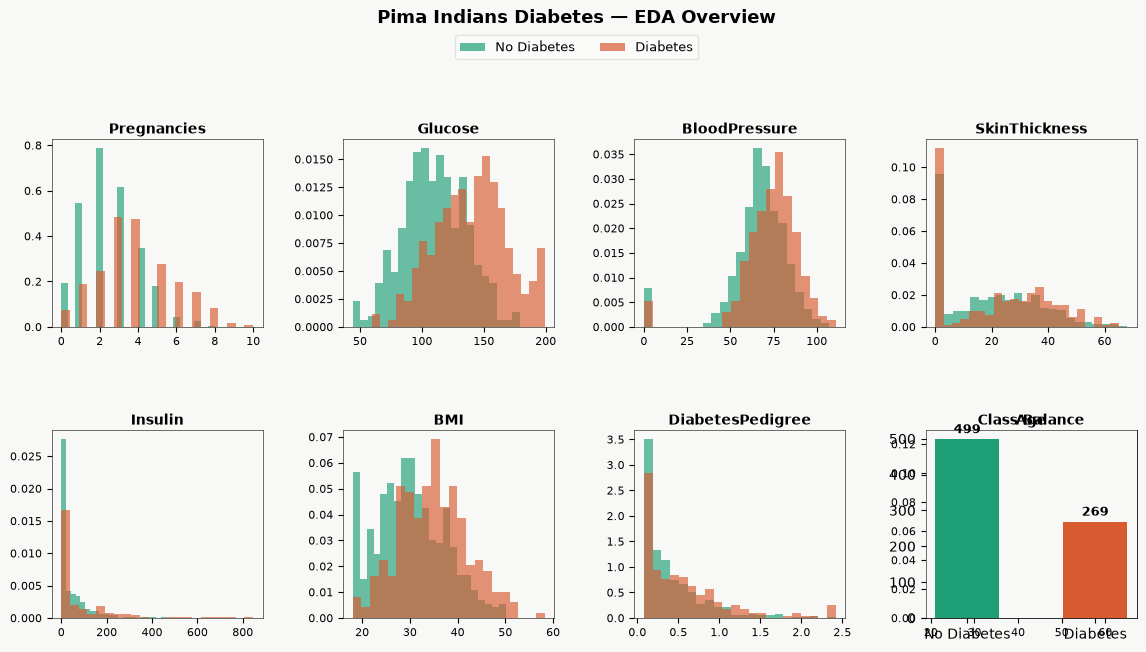

Saved: step1_eda.png


In [8]:
feature_cols = [c for c in df.columns if c != "Outcome"]
colors = ["#1D9E75", "#D85A30"]

fig = plt.figure(figsize=(14, 10))
fig.patch.set_facecolor("#F8F8F6")
gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.55, wspace=0.38)

for i, col in enumerate(feature_cols):
    ax = fig.add_subplot(gs[i // 4, i % 4])
    for outcome, color in zip([0, 1], colors):
        subset = df[df["Outcome"] == outcome][col]
        ax.hist(subset, bins=22, alpha=0.65, color=color,
                label=["No Diabetes", "Diabetes"][outcome], density=True)
    ax.set_title(col, fontsize=10, fontweight="bold", pad=4)
    ax.tick_params(labelsize=8)
    ax.set_facecolor("#F8F8F6")
    for spine in ax.spines.values():
        spine.set_linewidth(0.4)

# Class balance bar
ax_bar = fig.add_subplot(gs[1, 3])
bars = ax_bar.bar(["No Diabetes", "Diabetes"], [counts[0], counts[1]],
                  color=colors, width=0.5)
for bar, val in zip(bars, [counts[0], counts[1]]):
    ax_bar.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 8, str(val),
                ha="center", va="bottom", fontsize=9, fontweight="bold")
ax_bar.set_title("Class Balance", fontsize=10, fontweight="bold", pad=4)
ax_bar.set_facecolor("#F8F8F6")
for spine in ax_bar.spines.values():
    spine.set_linewidth(0.4)

legend_elements = [Patch(facecolor="#1D9E75", alpha=0.7, label="No Diabetes"),
                   Patch(facecolor="#D85A30", alpha=0.7, label="Diabetes")]
fig.legend(handles=legend_elements, loc="upper center",
           ncol=2, fontsize=9, framealpha=0.5, bbox_to_anchor=(0.5, 0.99))

fig.suptitle("Pima Indians Diabetes — EDA Overview", fontsize=13,
             fontweight="bold", y=1.01)
plt.savefig("step1_eda.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("Saved: step1_eda.png")